In [9]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('no2kamal.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'NO2'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_no2kamal_TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 172
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk NO2: 68


[NO2] Jumlah outlier terdeteksi: 10 dari 194 data


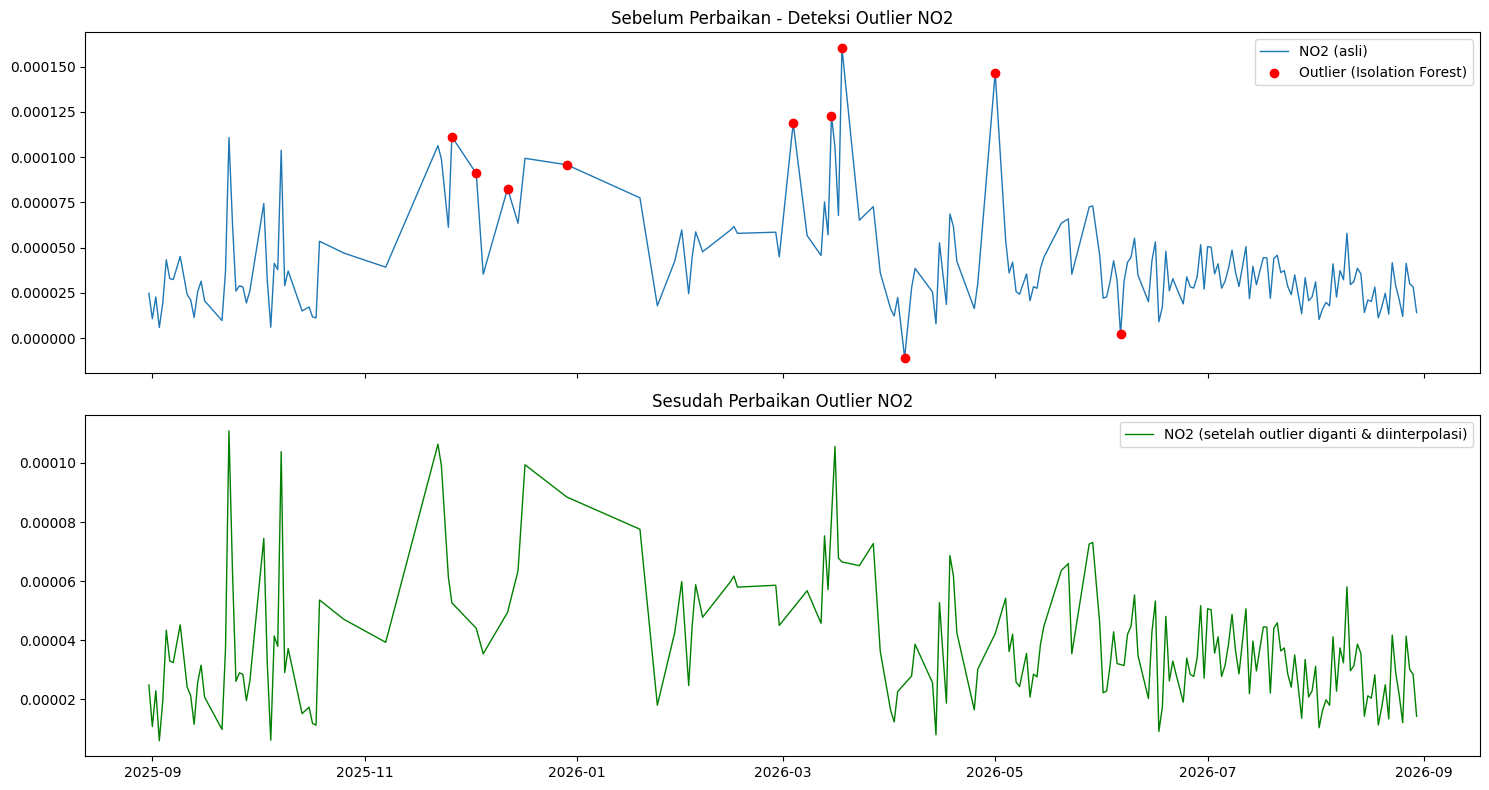

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

CONTAMINATION = 0.05
pol = "NO2"

# 1. Load data hasil crawling
df = pd.read_csv("no2_kamal.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df[pol] = pd.to_numeric(df[pol], errors="coerce")
df = df.dropna(subset=[pol]).copy()

# 2. Deteksi outlier dengan Isolation Forest
model = IsolationForest(contamination=CONTAMINATION, random_state=42)
pred = model.fit_predict(df[[pol]])
df["anomaly"] = pred  # -1 = outlier, 1 = normal
outliers = df[df["anomaly"] == -1]
print(f"[{pol}] Jumlah outlier terdeteksi: {len(outliers)} dari {len(df)} data")

# 3. Ganti outlier jadi NaN, lalu interpolasi
df_fixed = df.copy()
df_fixed.loc[df_fixed["anomaly"] == -1, pol] = np.nan
df_fixed[pol] = df_fixed[pol].interpolate(method="linear").ffill().bfill()

# 4. Plot sebelum vs sesudah
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
axes[0].plot(df["date"], df[pol], label=f"{pol} (asli)", linewidth=1)
axes[0].scatter(outliers["date"], outliers[pol], color="red",
                marker="o", label="Outlier (Isolation Forest)", zorder=5)
axes[0].set_title(f"Sebelum Perbaikan - Deteksi Outlier {pol}")
axes[0].legend()

axes[1].plot(df_fixed["date"], df_fixed[pol], color="green", linewidth=1,
             label=f"{pol} (setelah outlier diganti & diinterpolasi)")
axes[1].set_title(f"Sesudah Perbaikan Outlier {pol}")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"outlier_{pol}_before_after.png", dpi=150)
plt.show()

df_fixed[["date", pol]].to_csv(f"{pol}_Kamal_Timeseries_fixed.csv", index=False)

In [ ]:
import pandas as pd

pol = "NO2"
result_df = pd.read_csv(f"{pol}_Kamal_TSFEL.csv")

STATISTICAL = [
    "abs_energy", "average_power", "calc_max", "calc_mean", "calc_median",
    "calc_min", "calc_std", "calc_var", "ecdf", "ecdf_percentile",
    "ecdf_percentile_count", "ecdf_slope", "entropy", "hist_mode",
    "interq_range", "kurtosis", "mean_abs_deviation", "median_abs_deviation",
    "pk_pk_distance", "rms", "skewness"
]
TEMPORAL = [
    "auc", "autocorr", "calc_centroid", "dfa", "distance",
    "higuchi_fractal_dimension", "hurst_exponent", "lempel_ziv",
    "maximum_fractal_length", "mean_abs_diff", "mean_diff",
    "median_abs_diff", "median_diff", "mse", "negative_turning",
    "neighbourhood_peaks", "petrosian_fractal_dimension",
    "positive_turning", "slope", "sum_abs_diff", "zero_cross"
]
SPECTRAL = [
    "fundamental_frequency", "human_range_energy", "lpcc", "max_frequency",
    "max_power_spectrum", "median_frequency", "mfcc", "power_bandwidth",
    "spectral_centroid", "spectral_decrease", "spectral_distance",
    "spectral_entropy", "spectral_kurtosis", "spectral_positive_turning",
    "spectral_roll_off", "spectral_roll_on", "spectral_skewness",
    "spectral_slope", "spectral_spread", "spectral_variation",
    "spectrogram_mean_coeff", "wavelet_abs_mean", "wavelet_energy",
    "wavelet_entropy", "wavelet_std", "wavelet_var"
]

print(f"=== Statistical Domain ({len(STATISTICAL)} fitur) ===")
for f in STATISTICAL:
    print(f"| {f} | {result_df[f].values[0]} |")

print(f"\n=== Temporal Domain ({len(TEMPORAL)} fitur) ===")
for f in TEMPORAL:
    print(f"| {f} | {result_df[f].values[0]} |")

print(f"\n=== Spectral Domain ({len(SPECTRAL)} fitur) ===")
for f in SPECTRAL:
    print(f"| {f} | {result_df[f].values[0]} |")

=== Statistical Domain (21 fitur) ===
| abs_energy | 8.004483812520137e-07 |
| average_power | 2.193009263704147e-09 |
| calc_max | 8.261699258582667e-05 |
| calc_mean | 4.304078602292036e-05 |
| calc_median | 4.281815054127946e-05 |
| calc_min | -1.074266492651077e-05 |
| calc_std | 1.8289564610563453e-05 |
| calc_var | 3.3450817364397506e-10 |
| ecdf | 0.0150273224043715 |
| ecdf_percentile | 4.262600214133272e-05 |
| ecdf_percentile_count | 182.5 |
| ecdf_slope | 16798.33038578079 |
| entropy | 0.9993583051330968 |
| hist_mode | 4.060514670527482e-05 |
| interq_range | 2.93190165393753e-05 |
| kurtosis | -0.7653806440586406 |
| mean_abs_deviation | 1.527524349419392e-05 |
| median_abs_deviation | 1.4418096179724671e-05 |
| pk_pk_distance | 9.335965751233744e-05 |
| rms | 4.6765558214510725e-05 |
| skewness | -0.0484239574991572 |

=== Temporal Domain (21 fitur) ===
| auc | 0.0157404357614723 |
| autocorr | 11.0 |
| calc_centroid | 166.6274749901177 |
| dfa | 1.0650859251687137 |
| d

In [4]:
import pandas as pd

result_df = pd.read_csv("NO2_Kamal_TSFEL.csv")
print("Jumlah kolom:", result_df.shape[1])
print("Nama kolom:")
print(list(result_df.columns))

Jumlah kolom: 68
Nama kolom:
['abs_energy', 'auc', 'autocorr', 'average_power', 'calc_centroid', 'calc_max', 'calc_mean', 'calc_median', 'calc_min', 'calc_std', 'calc_var', 'dfa', 'distance', 'ecdf', 'ecdf_percentile', 'ecdf_percentile_count', 'ecdf_slope', 'entropy', 'fundamental_frequency', 'higuchi_fractal_dimension', 'hist_mode', 'human_range_energy', 'hurst_exponent', 'interq_range', 'kurtosis', 'lempel_ziv', 'lpcc', 'max_frequency', 'max_power_spectrum', 'maximum_fractal_length', 'mean_abs_deviation', 'mean_abs_diff', 'mean_diff', 'median_abs_deviation', 'median_abs_diff', 'median_diff', 'median_frequency', 'mfcc', 'mse', 'negative_turning', 'neighbourhood_peaks', 'petrosian_fractal_dimension', 'pk_pk_distance', 'positive_turning', 'power_bandwidth', 'rms', 'skewness', 'slope', 'spectral_centroid', 'spectral_decrease', 'spectral_distance', 'spectral_entropy', 'spectral_kurtosis', 'spectral_positive_turning', 'spectral_roll_off', 'spectral_roll_on', 'spectral_skewness', 'spectral_